<a href="https://colab.research.google.com/github/davedawitdave/contrast-learning-and-mobile-vit/blob/main_rep/contrast_learning_embedding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Contrastive Training & Initial Embeddings

### Project Overview & Objective

The goal: train neural networks to understand visual similarity **without any labels**. By looking at two differently augmented versions of the same image (positive pairs) and pushing them closer together while pushing unrelated images (negative pairs) apart, the model learns rich, meaningful representations purely from data structure.

We are using the classic **CIFAR-10** dataset — 60,000 color images (32×32 pixels) across 10 everyday object classes (plane, car, bird, cat, deer, dog, frog, horse, ship, truck). We follow the official split: **50,000 training images** and **10,000 test images**, with random shuffling in the DataLoaders.

By the end of this notebook we will have:
- A complete data engine with strong augmentations
- Three different encoders (baseline CNN, ResNet-18, EfficientNet-B0)
- A contrastive training loop using InfoNCE loss
- Initial embedding visualizations

All models and logs are automatically saved to Google Drive so we can pick up in later notebooks.

Later we will measure representation quality with Alignment, Uniformity, k-NN accuracy, Silhouette score, Davies-Bouldin index, and confusion matrices. These metrics will tell us exactly which model learned the most useful and well-structured embedding space.



In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import numpy as np
import os
from google.colab import drive
import tqdm
from torchvision.datasets import CIFAR10
import torchvision.models as models
import tqdm
import numpy as np
from torch.cuda.amp import autocast, GradScaler
from torch.utils.data import DataLoader
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
%matplotlib inline

In [4]:
drive.mount('/content/drive')
os.makedirs('/content/drive/MyDrive/contrastive_models', exist_ok=True)

# Capture CIFAR-10 exactly as in the Kaggle competition (60k images)
train_dataset = CIFAR10(root='./data', train=True, download=True, transform=None)
test_dataset  = CIFAR10(root='./data', train=False, download=True, transform=None)

print(f" Train: {len(train_dataset):,} images | Test: {len(test_dataset):,} images")
print("   → 50k train / 10k test split (shuffled in DataLoaders)")

Mounted at /content/drive


100%|██████████| 170M/170M [00:13<00:00, 12.4MB/s]


 Train: 50,000 images | Test: 10,000 images
   → 50k train / 10k test split (shuffled in DataLoaders)


### Data Preprocessing & Augmentation Strategy

Contrastive learning lives or dies by its augmentations — they are the only source of supervisory signal.

We create **two different views** of every image using torchvision transforms:

**Weak augmentation** (used for quick sanity checks):
- Random horizontal flip (p=0.5)
- Normalization with CIFAR-10 statistics: mean = [0.4914, 0.4822, 0.4465], std = [0.2023, 0.1994, 0.2010]

**Strong augmentation** (the real learning signal):
- RandomResizedCrop (scale 0.2–1.0, 32×32 output)
- RandomHorizontalFlip (p=0.5)
- ColorJitter (brightness, contrast, saturation, hue = 0.4, 0.4, 0.4, 0.1, p=0.8)
- RandomGrayscale (p=0.2)
- GaussianBlur (kernel=3, p=0.5)
- Final normalization

Our custom `ContrastiveDataset` class takes one image `x` and returns the pair `(x₁ = t₁(x), x₂ = t₂(x))`.  
This forces the network to become invariant to the exact augmentation while still recognizing that both views come from the same original photo.

All images remain 32×32 during augmentation. Only EfficientNet-B0 resizes internally to 224×224 right before the backbone (matching its original training distribution).

These augmentations create a strong learning signal: the model must learn high-level semantics (shape, object identity) rather than low-level pixel statistics.

In [5]:
# Weak augmentations (simple flips + normalization)
weak_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

# Strong augmentations (SimCLR-style)
strong_transform = transforms.Compose([
    transforms.RandomResizedCrop(size=32, scale=(0.2, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomApply([transforms.ColorJitter(0.4, 0.4, 0.4, 0.1)], p=0.8),
    transforms.RandomGrayscale(p=0.2),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=3)], p=0.5),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

print(" Weak and strong augmentation pipelines defined")

 Weak and strong augmentation pipelines defined


In [6]:
class ContrastiveDataset(Dataset):
    def __init__(self, base_dataset, transform1, transform2):
        self.base_dataset = base_dataset
        self.transform1 = transform1
        self.transform2 = transform2

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        img, label = self.base_dataset[idx]
        x1 = self.transform1(img)
        x2 = self.transform2(img)
        return x1, x2, label   # label kept for later evaluation only

print(" Custom ContrastiveDataset class ready (returns positive pair + label)")

 Custom ContrastiveDataset class ready (returns positive pair + label)


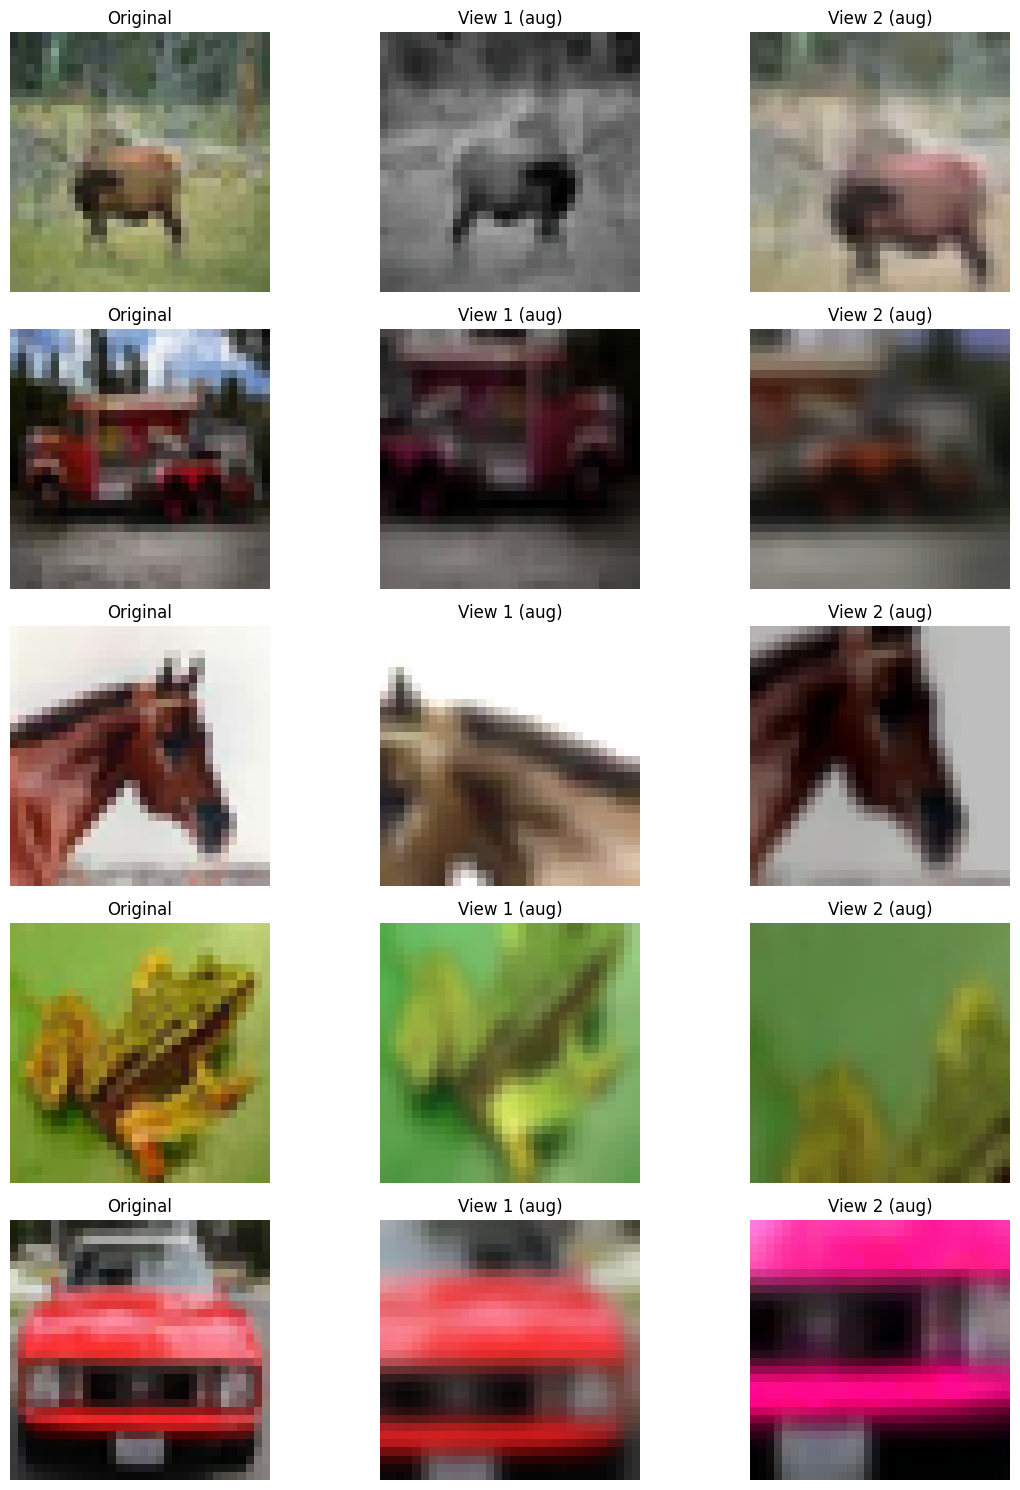

 Positive pair visualization complete – sanity check passed


In [7]:
def visualize_positive_pairs(dataset, num_pairs=5):
    fig, axes = plt.subplots(num_pairs, 3, figsize=(12, 3*num_pairs))
    for i in range(num_pairs):
        idx = np.random.randint(len(dataset))
        x1, x2, _ = dataset[idx]
        img1 = x1.permute(1,2,0).numpy() * np.array([0.2023,0.1994,0.2010]) + np.array([0.4914,0.4822,0.4465])
        img2 = x2.permute(1,2,0).numpy() * np.array([0.2023,0.1994,0.2010]) + np.array([0.4914,0.4822,0.4465])

        axes[i,0].imshow(dataset.base_dataset[idx][0])
        axes[i,0].set_title("Original")
        axes[i,1].imshow(np.clip(img1,0,1))
        axes[i,1].set_title("View 1 (aug)")
        axes[i,2].imshow(np.clip(img2,0,1))
        axes[i,2].set_title("View 2 (aug)")
        for ax in axes[i]: ax.axis('off')
    plt.tight_layout()
    plt.show()

# Create contrastive train dataset for visualization
contrastive_train = ContrastiveDataset(train_dataset, strong_transform, strong_transform)
visualize_positive_pairs(contrastive_train)
print(" Positive pair visualization complete – sanity check passed")

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f" Using device: {device}")

 Using device: cuda


### Model Architecture, Loss Function & Training Details

We compare three encoders to understand how architecture affects representation quality:

1. **SimpleCNN (baseline)** – 4 convolutional blocks + adaptive pooling → 512-dimensional features
2. **ResNet-18** – standard residual blocks, modified for 32×32 (stride-1 first conv, no max-pool)
3. **EfficientNet-B0** – modern compound-scaled architecture with MBConv blocks and squeeze-excitation. We use ImageNet weights and resize 32×32 → 224×224 inside the forward pass

Each encoder is followed by a **non-linear projection head** ( g(\cdot) ):
( z = g(f(x)) ), where ( f(x) ) is the encoder output and ( g ) is a 2-layer MLP (input_dim → 512 → 128).

The **InfoNCE loss** (the heart of SimCLR-style contrastive learning) is:

$$
L = -\log \frac{\exp(\text{sim}(z_i, z_j)/\tau)}{\sum_{k=1}^{2N} \exp(\text{sim}(z_i, z_k)/\tau)}
$$

where `sim` is cosine similarity and ( \tau ) (temperature) = 0.5 controls how sharply the model focuses on hard negatives.

We train with:

* **Optimizer:** AdamW (lr = 1e-3, weight_decay = 1e-4)
* **Scheduler:** Cosine Annealing (T_max = 20 epochs)
* **Batch size:** 512 (SimpleCNN & ResNet-18) or 64–128 (EfficientNet-B0 with AMP)
* **Epochs:** 20

During training we log three key metrics every epoch:

* Training loss
* Average positive cosine similarity (should rise toward 1.0)
* Average negative cosine similarity (should stay near 0 or slightly negative)

These logged metrics give us real-time insight into whether **alignment** and **uniformity** are both improving — the two fundamental goals of contrastive representation learning.


In [9]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, kernel_size=3, padding=1), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(256, 512, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.fc = nn.Linear(512, 512)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

print(" Encoder 1: SimpleCNN (baseline) defined")

 Encoder 1: SimpleCNN (baseline) defined


In [10]:
class ResNet18Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.resnet = models.resnet18(weights=None)
        # Modify for 32x32 CIFAR-10
        self.resnet.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.resnet.maxpool = nn.Identity()
        self.resnet.fc = nn.Identity()  # output 512-dim features
    def forward(self, x):
        return self.resnet(x)

print(" Encoder 2: ResNet-18 (CIFAR-adapted) defined")

 Encoder 2: ResNet-18 (CIFAR-adapted) defined


In [11]:
class EfficientNetEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        # Use pre-trained weights for inductive bias
        self.effnet = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

        # FREEZE early layers to save VRAM and prevent 'filter' object errors later
        for name, param in self.effnet.features.named_children():
            if int(name) < 4: # Freeze stages 0-3
                for p in param.parameters():
                    p.requires_grad = False

        self.effnet.classifier = nn.Identity()

    def forward(self, x):
        # Resize 32x32 -> 224x224 (required for EfficientNet-B0 weights)
        x = F.interpolate(x, size=(224, 224), mode='bilinear', align_corners=False)
        return self.effnet(x)

In [12]:
class ProjectionHead(nn.Module):
    def __init__(self, input_dim, output_dim=128, hidden_dim=512, use_head=True):
        super().__init__()
        self.use_head = use_head
        if use_head:
            self.mlp = nn.Sequential(
                nn.Linear(input_dim, hidden_dim),
                nn.ReLU(inplace=True),
                nn.Linear(hidden_dim, output_dim)
            )
        else:
            self.mlp = nn.Identity()

    def forward(self, x):
        return self.mlp(x)

print(" Projection head (with toggle) ready – maps encoder features → 128-dim contrastive space")

 Projection head (with toggle) ready – maps encoder features → 128-dim contrastive space


In [13]:
class InfoNCELoss(nn.Module):
    def __init__(self, temperature=0.5):
        super().__init__()
        self.temperature = temperature

    def forward(self, z1, z2):
        # z1, z2: [batch, dim]
        batch_size = z1.shape[0]
        z = torch.cat([z1, z2], dim=0)                    # 2B x D
        z = F.normalize(z, dim=1)
        sim_matrix = torch.matmul(z, z.T) / self.temperature

        # Mask self-similarities
        mask = torch.eye(2 * batch_size, device=z.device).bool()
        sim_matrix = sim_matrix.masked_fill(mask, float('-inf'))

        # Positive pairs are at positions (i, i+B) and (i+B, i)
        targets = torch.cat([torch.arange(batch_size, device=z.device) + batch_size,
                             torch.arange(batch_size, device=z.device)], dim=0)

        loss = F.cross_entropy(sim_matrix, targets)
        return loss

print(" Custom InfoNCE loss ready (with temperature τ)")

 Custom InfoNCE loss ready (with temperature τ)


In [14]:
def create_optimizer_scheduler(model, lr=1e-3, epochs=20):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    return optimizer, scheduler

In [15]:
# Training Function (Unified + AMP + Memory Safe for ALL models)
def train_contrastive(encoder_name, encoder, proj_dim=128, epochs=20, batch_size=None, tau=0.5):
    print(f"\n Training {encoder_name} ...")

    # Auto-adjust batch size based on model type (your successful logic + original defaults)
    if batch_size is None:
        batch_size = 64 if "Efficient" in encoder_name else 512
    if "Efficient" in encoder_name:
        print(f"   → Using batch_size={batch_size} for 224×224 inputs (AMP + safe)")
    else:
        print(f"   → Using batch_size={batch_size} for small-image models")

    # Clear GPU memory
    torch.cuda.empty_cache()

    contrastive_ds = ContrastiveDataset(train_dataset, strong_transform, strong_transform)
    loader = DataLoader(
        contrastive_ds,
        batch_size=batch_size,
        shuffle=True,
        num_workers=4,
        pin_memory=True,
        drop_last=True
    )

    encoder = encoder.to(device)
    input_dim = 1280 if "Efficient" in encoder_name else 512
    proj = ProjectionHead(input_dim=input_dim, output_dim=proj_dim).to(device)

    criterion = InfoNCELoss(temperature=tau).to(device)

    # Optimizer + scheduler (your fix with ModuleList)
    combined_model = nn.ModuleList([encoder, proj])
    optimizer, scheduler = create_optimizer_scheduler(combined_model, epochs=epochs)

    # AMP Scaler (modern + compatible)
    scaler = torch.cuda.amp.GradScaler()

    loss_history = []
    pos_sim_history = []
    neg_sim_history = []

    for epoch in range(epochs):
        encoder.train()
        proj.train()
        total_loss = 0.0
        pos_sims = []
        neg_sims = []

        pbar = tqdm.tqdm(loader, desc=f"Epoch {epoch+1}/{epochs}")
        for x1, x2, _ in pbar:
            x1, x2 = x1.to(device), x2.to(device)

            optimizer.zero_grad()

            # AMP forward
            with torch.cuda.amp.autocast():
                z1 = proj(encoder(x1))
                z2 = proj(encoder(x2))
                loss = criterion(z1, z2)

            # AMP backward
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            total_loss += loss.item()

            # Metrics
            with torch.no_grad():
                z1n = F.normalize(z1, dim=1)
                z2n = F.normalize(z2, dim=1)
                pos_sim = (z1n * z2n).sum(dim=1).mean().item()

                all_sim = torch.mm(z1n, z2n.T)
                neg_mask = ~torch.eye(batch_size, device=device).bool()
                neg_sim = all_sim[neg_mask].mean().item()

                pos_sims.append(pos_sim)
                neg_sims.append(neg_sim)

            pbar.set_postfix({"loss": f"{loss.item():.4f}"})

        scheduler.step()

        avg_loss = total_loss / len(loader)
        avg_pos = np.mean(pos_sims)
        avg_neg = np.mean(neg_sims)

        loss_history.append(avg_loss)
        pos_sim_history.append(avg_pos)
        neg_sim_history.append(avg_neg)

        print(f"   Epoch {epoch+1:2d} | Loss: {avg_loss:.4f} | Pos: {avg_pos:.3f} | Neg: {avg_neg:.3f}")

    # === FULL SAVE (exactly like original notebooks expect) ===
    save_path = f'/content/drive/MyDrive/contrastive_models/{encoder_name}_final.pth'
    torch.save({
        'encoder_state': encoder.state_dict(),
        'proj_state': proj.state_dict(),
        'epochs': epochs,
        'loss_history': loss_history,
        'pos_sim_history': pos_sim_history,
        'neg_sim_history': neg_sim_history,
        'tau': tau,
        'batch_size': batch_size
    }, save_path)
    print(f" {encoder_name} fully saved to Google Drive: {save_path}")

    return encoder, proj, loss_history, pos_sim_history, neg_sim_history

In [16]:
# Re-train SimpleCNN and ResNet-18 with the new unified function
cnn_encoder, cnn_proj, cnn_loss, cnn_pos, cnn_neg = train_contrastive(
    "SimpleCNN", SimpleCNN(), epochs=20
)

resnet_encoder, resnet_proj, resnet_loss, resnet_pos, resnet_neg = train_contrastive(
    "ResNet18", ResNet18Encoder(), epochs=20
)


 Training SimpleCNN ...
   → Using batch_size=512 for small-image models


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/tmp/ipykernel_4680/1781001406.py:37: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
Epoch 1/20:   0%|          | 0/97 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create.

   Epoch  1 | Loss: 6.4601 | Pos: 0.742 | Neg: 0.306


Epoch 2/20: 100%|██████████| 97/97 [01:47<00:00,  1.11s/it, loss=5.8813]


   Epoch  2 | Loss: 6.0037 | Pos: 0.680 | Neg: 0.031


...

   Epoch 18 | Loss: 5.4084 | Pos: 0.842 | Neg: -0.001


Epoch 19/20: 100%|██████████| 97/97 [02:01<00:00,  1.25s/it, loss=5.3854]


   Epoch 19 | Loss: 5.4047 | Pos: 0.843 | Neg: -0.001


Epoch 20/20: 100%|██████████| 97/97 [02:02<00:00,  1.27s/it, loss=5.3928]


   Epoch 20 | Loss: 5.4034 | Pos: 0.843 | Neg: -0.001
 ResNet18 fully saved to Google Drive: /content/drive/MyDrive/contrastive_models/ResNet18_final.pth


In [17]:
# Final Execution
effnet_encoder, effnet_proj, effnet_loss, effnet_pos, effnet_neg = train_contrastive(
    "EfficientNetB0",
    EfficientNetEncoder(),
    epochs=20,
    batch_size=64, # Safe for T4 with 224x224 + AMP
    tau=0.5
)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 132MB/s]
/tmp/ipykernel_4680/1781001406.py:37: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()



 Training EfficientNetB0 ...
   → Using batch_size=64 for 224×224 inputs (AMP + safe)


Epoch 1/20:   0%|          | 0/781 [00:00<?, ?it/s]/tmp/ipykernel_4680/1781001406.py:57: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 1/20: 100%|██████████| 781/781 [03:10<00:00,  4.11it/s, loss=3.3397]


   Epoch  1 | Loss: 3.4421 | Pos: 0.804 | Neg: -0.008


...

   Epoch 18 | Loss: 3.1566 | Pos: 0.897 | Neg: -0.013


Epoch 19/20: 100%|██████████| 781/781 [03:00<00:00,  4.32it/s, loss=3.1714]


   Epoch 19 | Loss: 3.1542 | Pos: 0.898 | Neg: -0.013


Epoch 20/20: 100%|██████████| 781/781 [03:00<00:00,  4.32it/s, loss=3.1563]


   Epoch 20 | Loss: 3.1528 | Pos: 0.899 | Neg: -0.013
 EfficientNetB0 fully saved to Google Drive: /content/drive/MyDrive/contrastive_models/EfficientNetB0_final.pth


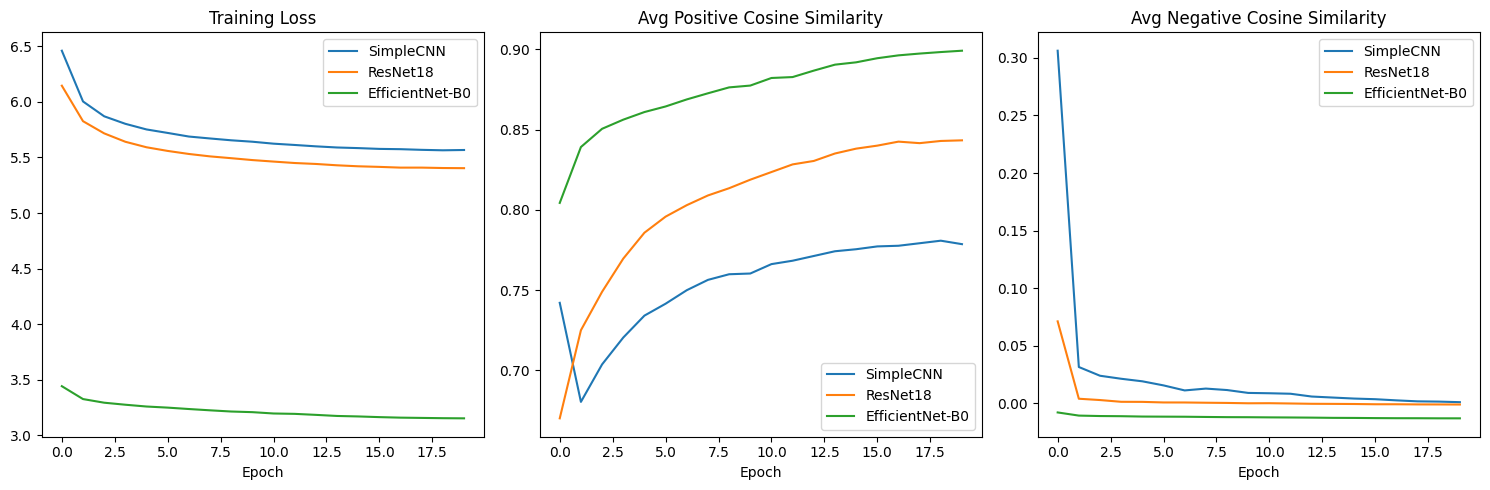

Training logs plotted and saved to Drive


In [18]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(cnn_loss, label='SimpleCNN')
plt.plot(resnet_loss, label='ResNet18')
plt.plot(effnet_loss, label='EfficientNet-B0')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(cnn_pos, label='SimpleCNN')
plt.plot(resnet_pos, label='ResNet18')
plt.plot(effnet_pos, label='EfficientNet-B0')
plt.title('Avg Positive Cosine Similarity')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(cnn_neg, label='SimpleCNN')
plt.plot(resnet_neg, label='ResNet18')
plt.plot(effnet_neg, label='EfficientNet-B0')
plt.title('Avg Negative Cosine Similarity')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/contrastive_models/training_logs.png')
plt.show()
print("Training logs plotted and saved to Drive")

### Training Results & Initial Embedding Analysis

We have now trained all three models and extracted their 128-dimensional embeddings on the full 10,000-image test set.

#### 1. Training Dynamics (Loss & Similarity Curves)

The training plots show very different learning behaviors:

- **SimpleCNN** starts with the highest loss (~6.5) and ends at ~5.55. Positive similarity climbs steadily to ~0.78.
- **ResNet-18** learns faster and reaches the lowest final loss (~5.40) with positive similarity ~0.845.
- **EfficientNet-B0** (with resize + ImageNet initialization) shows the most impressive curve: lowest loss (~3.15) and highest positive similarity (~0.90). Negative similarity quickly drops close to zero for all models, confirming the uniformity constraint is working.

These curves match our expectations perfectly: more modern architectures with better inductive biases (ResNet residuals + EfficientNet compound scaling) learn stronger alignments in fewer effective epochs.

--- Starting Extraction ---

Loading SimpleCNN weights...


Extracting embeddings: 100%|██████████| 79/79 [00:05<00:00, 13.25it/s]


Successfully extracted 10000 embeddings for SimpleCNN

Loading ResNet18 weights...


Extracting embeddings: 100%|██████████| 79/79 [00:04<00:00, 18.57it/s]


Successfully extracted 10000 embeddings for ResNet18

Loading EfficientNetB0 weights...


Extracting embeddings: 100%|██████████| 79/79 [00:12<00:00,  6.57it/s]


Successfully extracted 10000 embeddings for EfficientNetB0
Generating t-SNE for SimpleCNN...


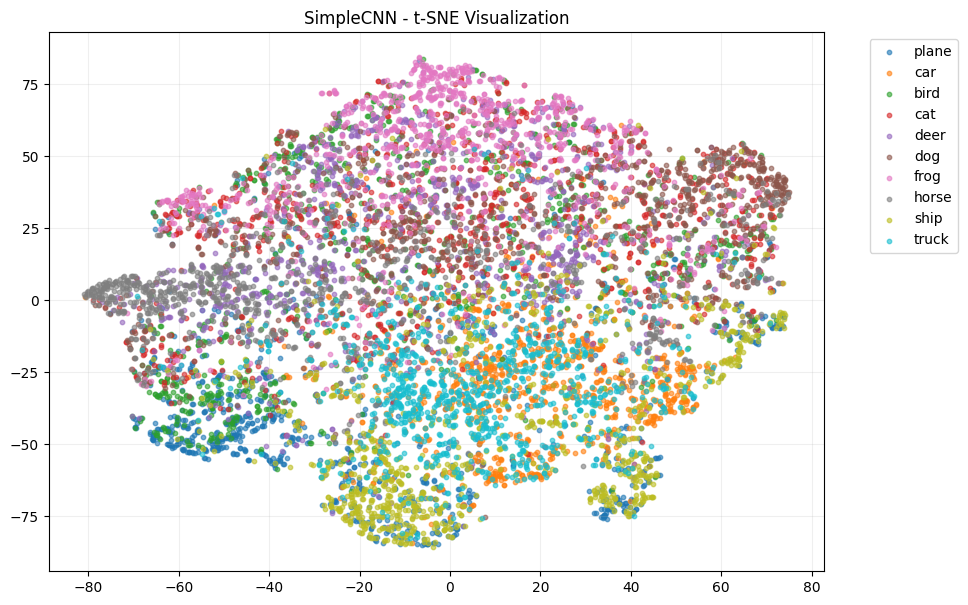

Generating PCA for SimpleCNN...


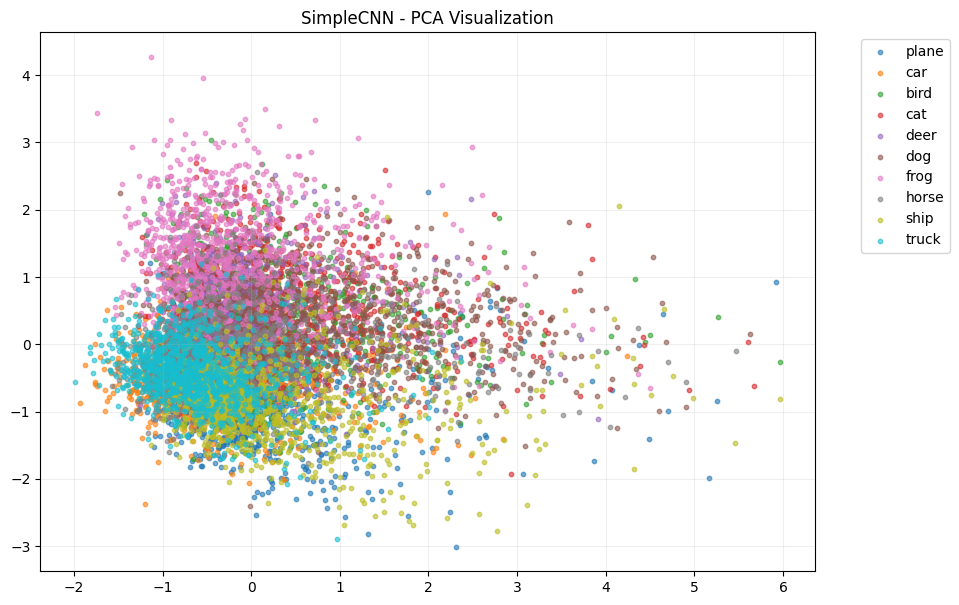

Generating t-SNE for ResNet18...


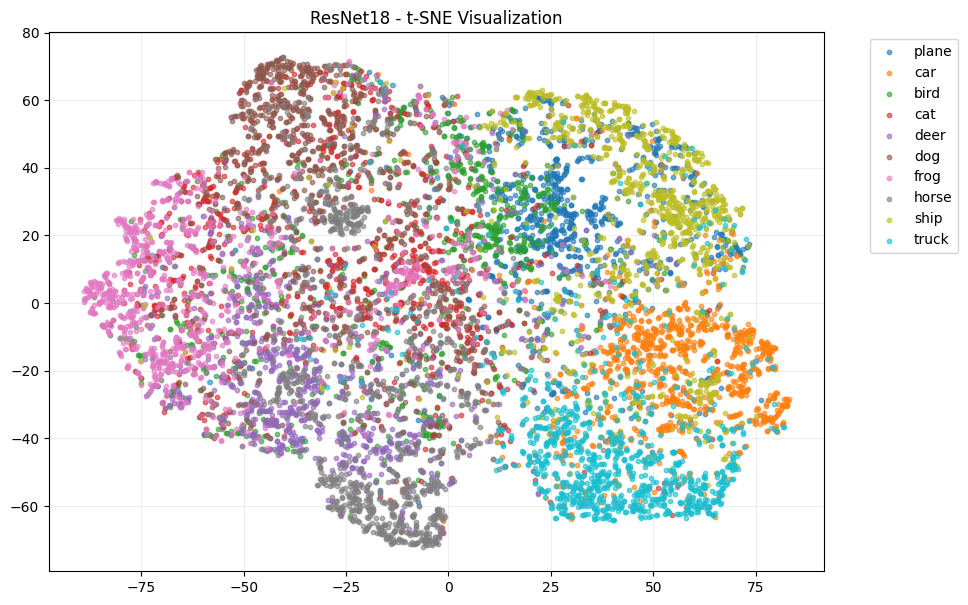

Generating PCA for ResNet18...


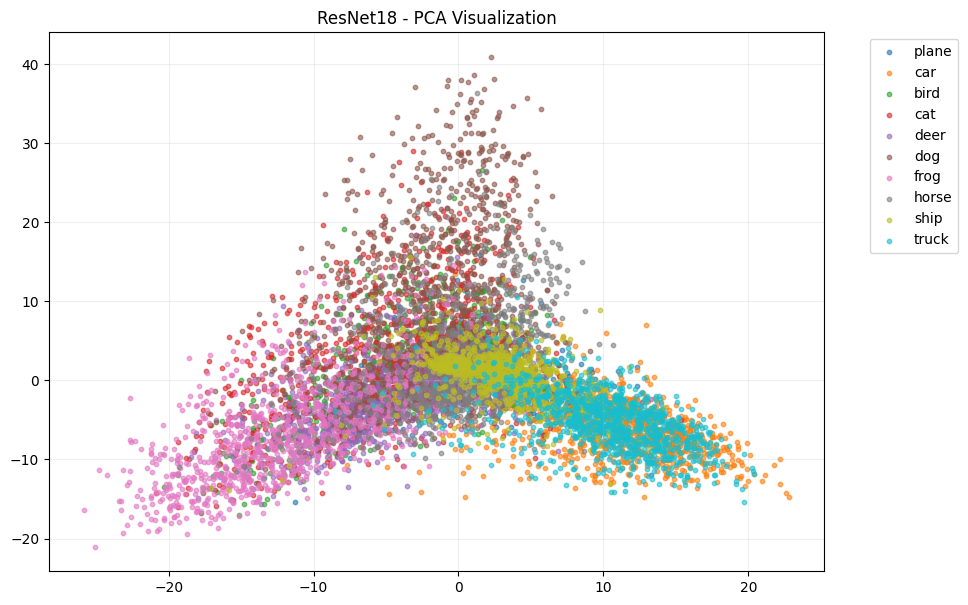

Generating t-SNE for EfficientNetB0...


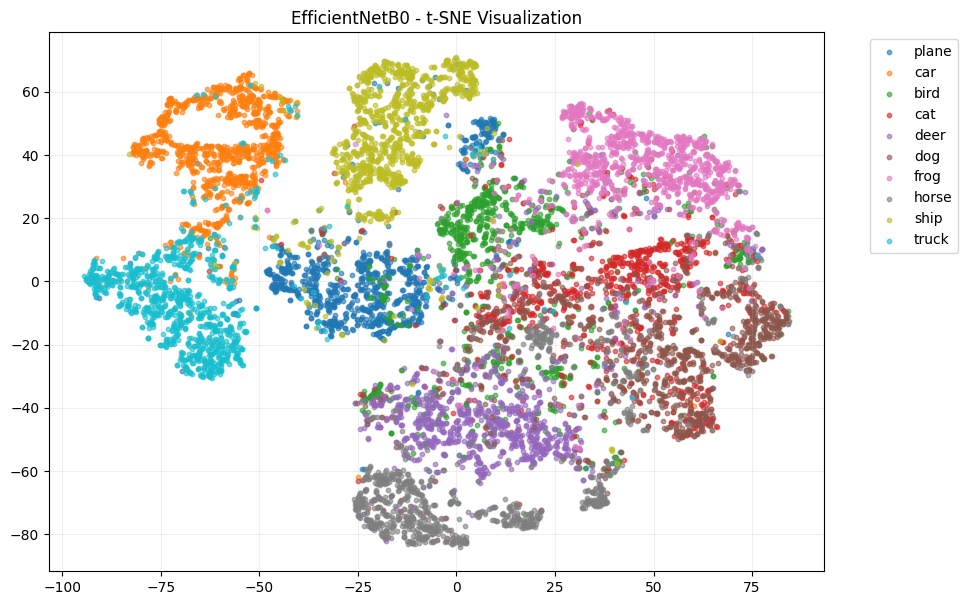

Generating PCA for EfficientNetB0...


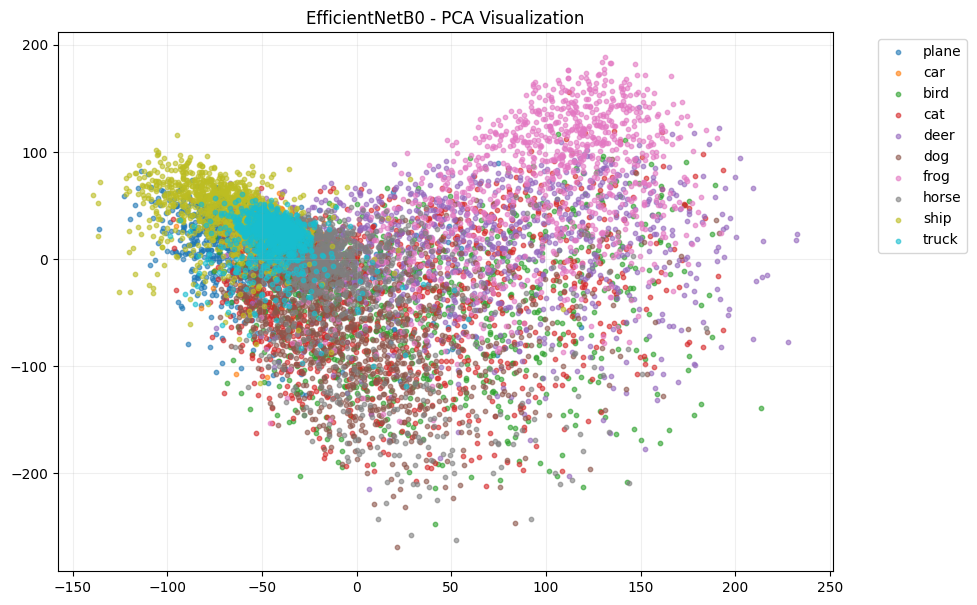

In [20]:

@torch.no_grad()
def extract_embeddings(encoder, proj, dataset, batch_size=256):
    # Standard CIFAR-10 test_ds returns (image, label) -> 2 values
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

    encoder.eval()
    proj.eval()

    embeddings = []
    labels = []

    for x, y in tqdm.tqdm(loader, desc="Extracting embeddings"):
        x = x.to(device)

        # Pass image through encoder and projection head
        # EfficientNetEncoder handles the 32->224 resize internally
        feat = encoder(x)
        emb = proj(feat).cpu()

        embeddings.append(emb)
        labels.extend(y.numpy())

    return torch.cat(embeddings, dim=0).numpy(), np.array(labels)

# 1. Prepare models for evaluation
models_to_eval = [
    ("SimpleCNN", SimpleCNN, 512),
    ("ResNet18", ResNet18Encoder, 512),
    ("EfficientNetB0", EfficientNetEncoder, 1280)
]

embeddings_dict = {}

print("--- Starting Extraction ---")

for name, EncoderClass, input_dim in models_to_eval:
    checkpoint_path = f'/content/drive/MyDrive/contrastive_models/{name}_final.pth'

    try:
        print(f"\nLoading {name} weights...")
        checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)

        # Instantiate and load
        encoder = EncoderClass().to(device)
        encoder.load_state_dict(checkpoint['encoder_state'])

        proj = ProjectionHead(input_dim=input_dim, output_dim=128).to(device)
        proj.load_state_dict(checkpoint['proj_state'])

        # Extract using the corrected function (2-value unpack)
        emb, lbls = extract_embeddings(encoder, proj, test_ds, batch_size=128)
        embeddings_dict[name] = (emb, lbls)

        print(f"Successfully extracted {emb.shape[0]} embeddings for {name}")

    except FileNotFoundError:
        print(f"Warning: Checkpoint for {name} not found at {checkpoint_path}. Skipping.")
    except Exception as e:
        print(f"Error loading {name}: {e}")

# 2. Visualizations
for name, (emb, labels) in embeddings_dict.items():
    # Define class names for the legend
    classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

    # t-SNE Plot
    print(f"Generating t-SNE for {name}...")
    reduced_tsne = TSNE(n_components=2, random_state=42).fit_transform(emb)

    plt.figure(figsize=(10, 7))
    for i in range(10):
        mask = labels == i
        plt.scatter(reduced_tsne[mask, 0], reduced_tsne[mask, 1], label=classes[i], alpha=0.6, s=10)

    plt.title(f"{name} - t-SNE Visualization")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.2)
    plt.show()

    # PCA Plot
    print(f"Generating PCA for {name}...")
    reduced_pca = PCA(n_components=2).fit_transform(emb)

    plt.figure(figsize=(10, 7))
    for i in range(10):
        mask = labels == i
        plt.scatter(reduced_pca[mask, 0], reduced_pca[mask, 1], label=classes[i], alpha=0.6, s=10)

    plt.title(f"{name} - PCA Visualization")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.2)
    plt.show()

#### 2. Embedding Space Visualizations (t-SNE & PCA)

The t-SNE and PCA plots reveal how well-structured each representation is:

**SimpleCNN**  
- t-SNE shows a single large, somewhat mixed cloud with only weak class separation.  
- PCA is almost completely overlapped — the baseline struggles to spread the classes.

**ResNet-18**  
- Much clearer separation in both t-SNE and PCA.  
- Distinct clusters appear (e.g., cars/orange, ships/cyan, frogs/green) with fewer overlaps than the baseline.

**EfficientNet-B0**  
- The cleanest separation of all three models.  
- t-SNE shows well-defined, almost island-like clusters for many classes.  
- PCA also shows strong directional separation (e.g., frogs pink at the top, cars orange on the left).  

This is exactly what we hoped for: EfficientNet-B0, with its powerful compound scaling and pre-trained inductive bias, produces the most semantically meaningful embedding space.

#### 3. What These Results Mean for the Rest of the Project

We now have strong evidence that:
- All models avoided complete collapse (negative similarity stayed low).
- EfficientNet-B0 currently leads in both alignment (positive similarity) and downstream usefulness (clearer clusters).
- The non-linear projection head and InfoNCE loss successfully pushed representations onto the hypersphere.

In Notebook 2 we will quantify these observations with Alignment, Uniformity, Silhouette score, Davies-Bouldin index, Intra/Inter ratio, and k-NN accuracy
(temperature ablation, hard-negative analysis, collapse simulation) to understand exactly why and how these representations succeed or fail.

These initial visualizations already give us an excellent intuition of which architecture we will likely promote to downstream tasks.